In [2]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 3.6 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [157]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import uuid
from sklearn.preprocessing import MultiLabelBinarizer

In [4]:
# zip_path = ".zip"

# with zipfile.ZipFile(zip_path, "r") as z:
#     with z.open(".csv") as f:
#         df = pd.read_csv(f)

# df.shape

In [264]:
file_path = 'df_labeled_all_final_25.csv'
df = pd.read_csv(file_path, on_bad_lines='warn')

In [136]:
df.head(5)

,id,judge,decision,gender_accused,prior_convictions,alcohol,precrime_argument,has_woman_victim,has_man_victim,method,motive,location,prison_term,many_victims,year,season,attempt,victim_child_or_helpless,cruel,region_name
0,92093,Толстых Артём Александрович,Вынесен ПРИГОВОР,1,0,0,1,0,1,тяжелые предметы,личная неприязнь,"рабочая зона, уличное пространство",9.000000,0,1998,Лето,0,0,0,Омская область
1,25775,Сон А.И.,Вынесен ПРИГОВОР,1,0,0,0,0,1,холодное оружие,личная неприязнь,"общественное место, уличное пространство",7.986857,0,1999,Зима,0,0,0,Еврейская автономная область
2,75488,Акимова Юна Юрьевна,Вынесен ПРИГОВОР,1,0,0,1,1,1,"физическое воздействие, холодное оружие","корысть, личная неприязнь",жилое помещение,13.000000,1,2000,Лето,1,0,0,Кемеровская область
3,126184,Цыренов Тимур Будажапович,Вынесен ПРИГОВОР,0,0,1,1,0,1,огнестрельное оружие,"корысть, личная неприязнь",уличное пространство,13.000000,0,2005,Лето,0,0,0,Республика Бурятия
4,102316,Ляховецкий Олег Павлович,Вынесен ПРИГОВОР,1,0,0,1,1,0,удушение,личная неприязнь,жилое помещение,8.311355,1,2009,Весна,0,0,0,Иркутская область


In [59]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'method', 'motive', 'location', 'prison_term', 'many_victims', 'year',
       'season', 'attempt', 'victim_child_or_helpless', 'cruel',
       'region_name'],
      dtype='object')

In [60]:
# df["gender_accused"] = np.where(df["gender_accused"] == "мужчина", 1, 0)
# df["prior_convictions"] = np.where(df["prior_convictions"] == "да", 1, 0)
# df["alcohol"] = np.where(df["alcohol"] == "да", 1, 0)

1. Распределение целевой переменной (сезоны)


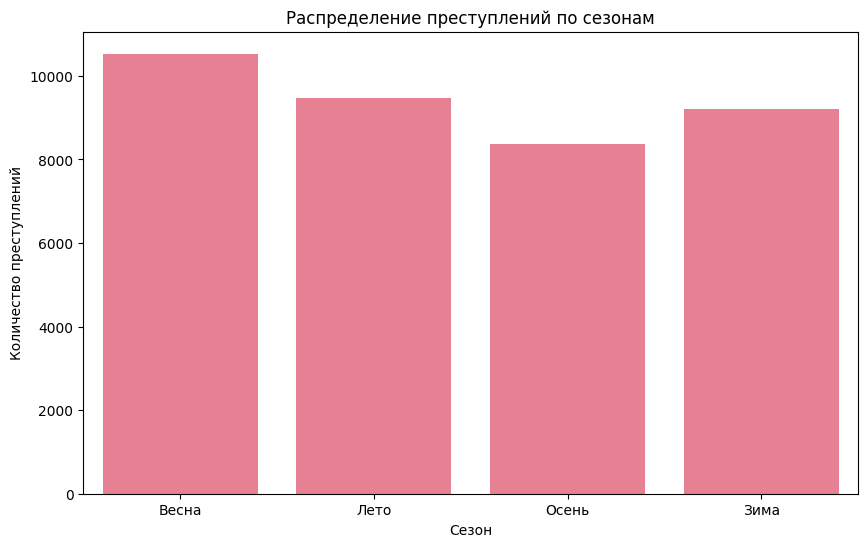

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='season', order=['Весна', 'Лето', 'Осень', 'Зима'])
plt.title('Распределение преступлений по сезонам')
plt.xlabel('Сезон')
plt.ylabel('Количество преступлений')
plt.show()

2. Зависимость сезона от пола обвиняемого

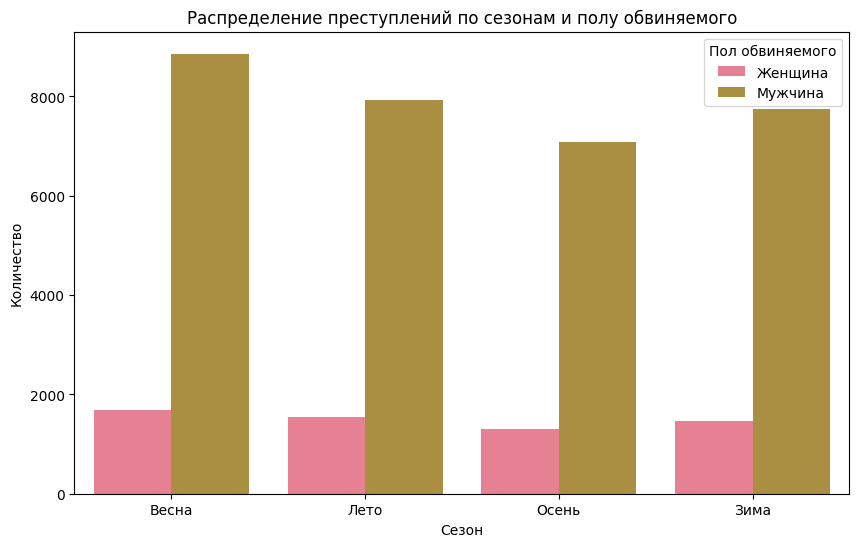

In [63]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='season', hue='gender_accused', 
             order=['Весна', 'Лето', 'Осень', 'Зима'])
plt.title('Распределение преступлений по сезонам и полу обвиняемого')
plt.xlabel('Сезон')
plt.ylabel('Количество')
plt.legend(title='Пол обвиняемого', labels=['Женщина', 'Мужчина'])
plt.show()

3. Распределение преступлений по сезонам и регионам

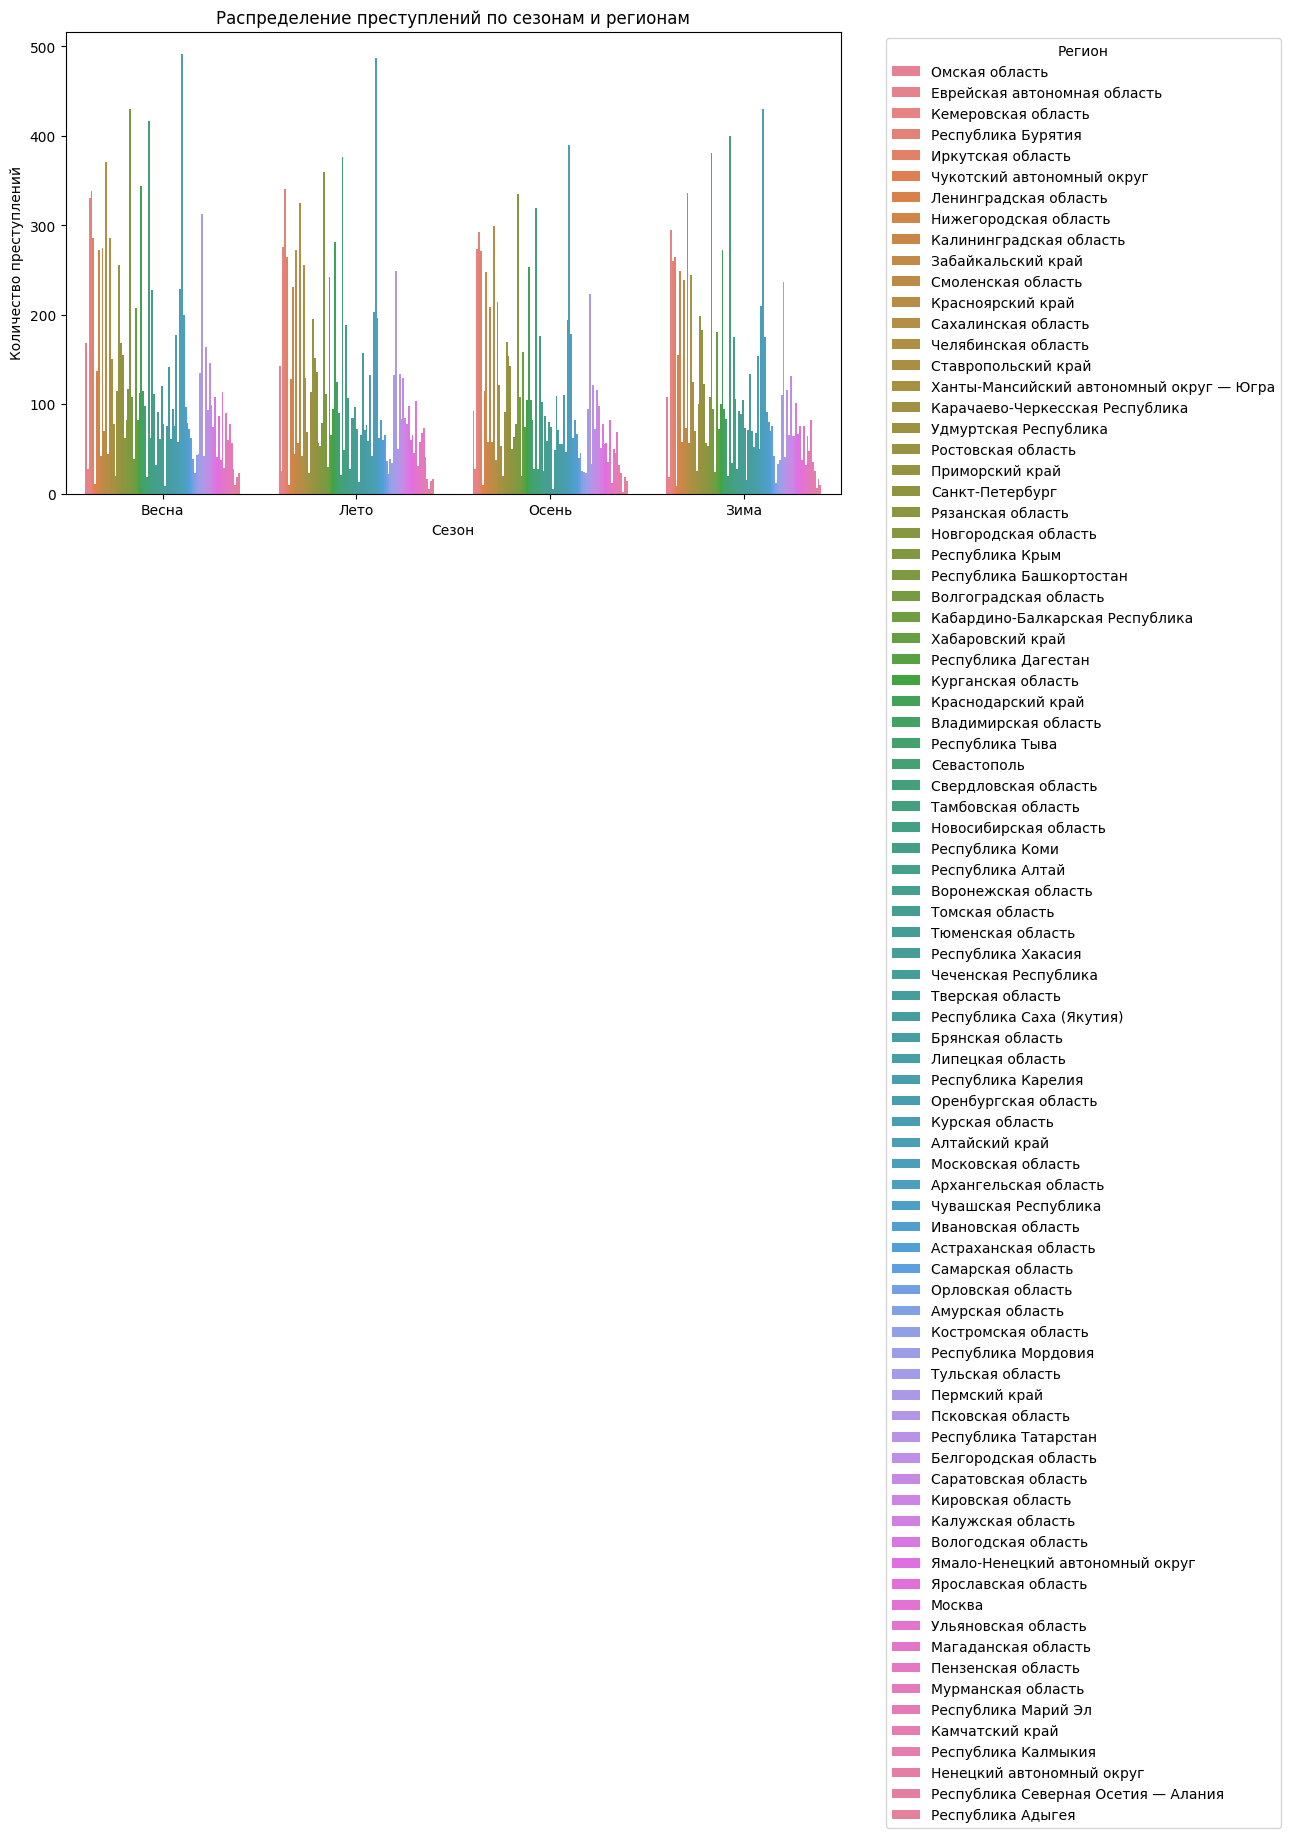

In [123]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='season', hue='region_name', order=['Весна', 'Лето', 'Осень', 'Зима'])
plt.title('Распределение преступлений по сезонам и регионам')
plt.xlabel('Сезон')
plt.ylabel('Количество преступлений')
plt.legend(title='Регион', bbox_to_anchor=(1.05, 1), loc='upper left')

4. Влияние алкоголя на сезонность преступлений

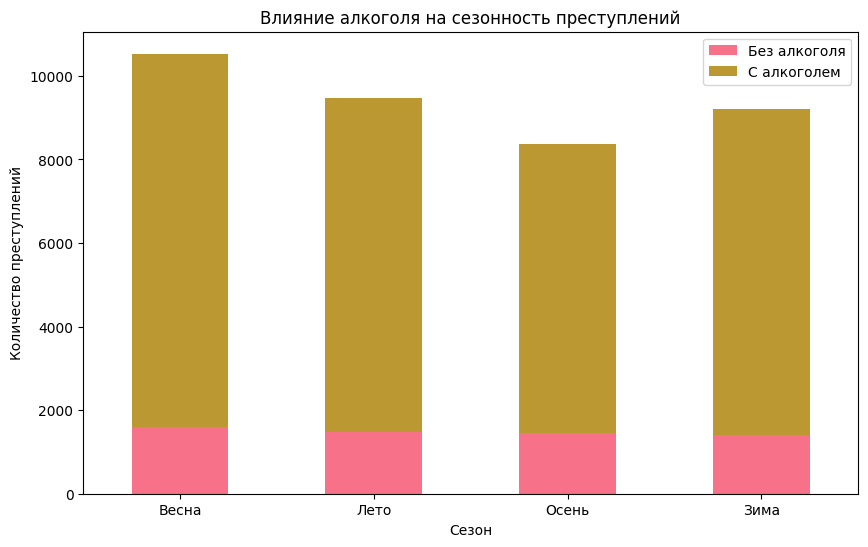

In [253]:
cross_tab = pd.crosstab(df['season'], df['alcohol']).reindex(['Весна', 'Лето', 'Осень', 'Зима'])
cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Влияние алкоголя на сезонность преступлений')
plt.xlabel('Сезон')
plt.ylabel('Количество преступлений')
plt.legend(['Без алкоголя', 'С алкоголем'])
plt.xticks(rotation=0)
plt.show()

5. Распределение сроков заключения по сезонам

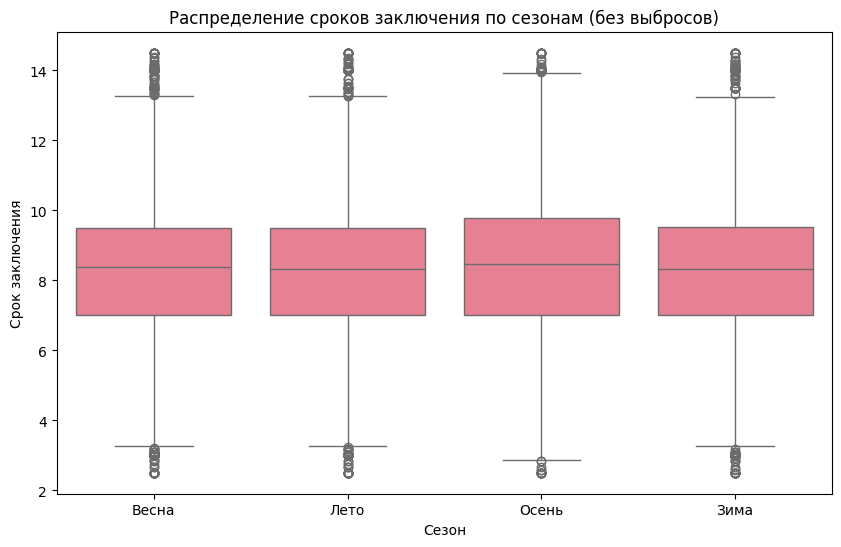

In [65]:
Q1 = df['prison_term'].quantile(0.25)
Q3 = df['prison_term'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[(df['prison_term'] >= lower_bound) & (df['prison_term'] <= upper_bound)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_filtered, x='season', y='prison_term', 
            order=['Весна', 'Лето', 'Осень', 'Зима'])
plt.title('Распределение сроков заключения по сезонам (без выбросов)')
plt.xlabel('Сезон')
plt.ylabel('Срок заключения')
plt.show()

6. Распределение года по сезонам

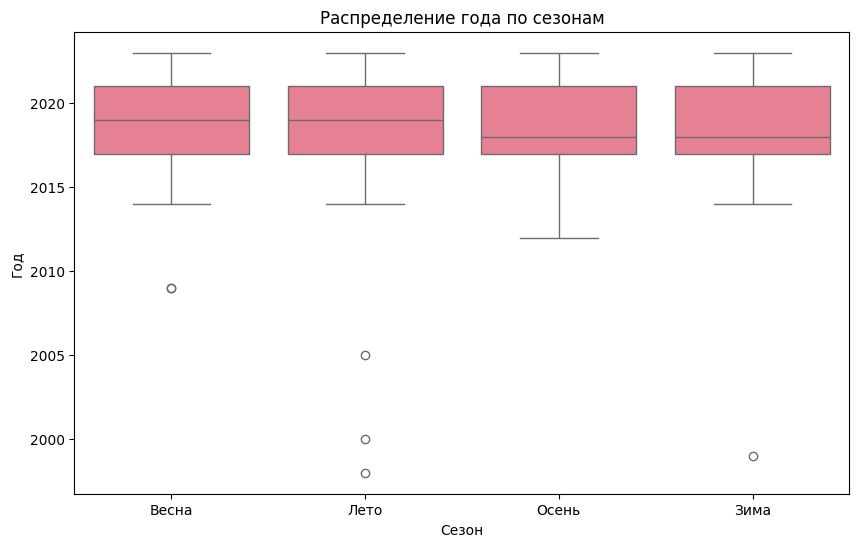

In [66]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='season', y='year', 
           order=['Весна', 'Лето', 'Осень', 'Зима'])
plt.title('Распределение года по сезонам')
plt.xlabel('Сезон')
plt.ylabel('Год')
plt.show()

Cramer's V between season and year: 0.093


Text(95.72222222222221, 0.5, 'Сезон')

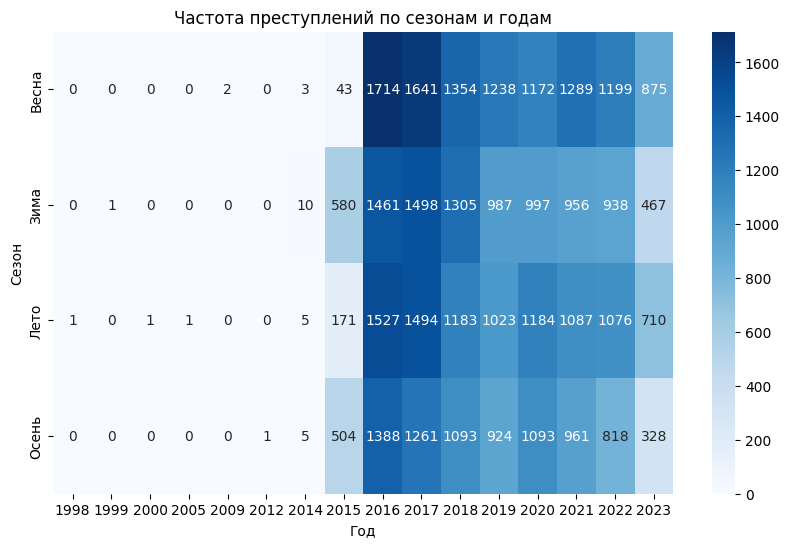

In [134]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

contingency_table = pd.crosstab(df['season'], df['year'])

cramer_v_value = cramers_v(df['season'], df['year'])
print(f"Cramer's V between season and year: {cramer_v_value:.3f}")


plt.figure(figsize=(10, 6))
sns.heatmap(contingency_table, annot=True, cmap='Blues', fmt='d')
plt.title('Частота преступлений по сезонам и годам')
plt.xlabel('Год')
plt.ylabel('Сезон')

7.

In [69]:
# Связь метода преступления с сезоном
pd.crosstab(df['season'], df['method'])

method,другое,"другое, огнестрельное оружие","другое, огнестрельное оружие, физическое воздействие","другое, огнестрельное оружие, физическое воздействие, холодное оружие","другое, огнестрельное оружие, холодное оружие","другое, тяжелые предметы","другое, тяжелые предметы, удушение, физическое воздействие, холодное оружие","другое, тяжелые предметы, физическое воздействие","другое, тяжелые предметы, физическое воздействие, холодное оружие","другое, тяжелые предметы, холодное оружие",...,"тяжелые предметы, физическое воздействие","тяжелые предметы, физическое воздействие, холодное оружие","тяжелые предметы, холодное оружие",удушение,"удушение, физическое воздействие","удушение, физическое воздействие, холодное оружие","удушение, холодное оружие",физическое воздействие,"физическое воздействие, холодное оружие",холодное оружие
season,,,,,,,,,,,,,,,,,,,,,
Весна,246,0,0,1,2,0,0,0,0,0,...,411,105,74,204,303,42,14,494,2397,5402
Зима,312,2,0,2,0,0,1,0,0,1,...,357,89,60,170,315,31,21,503,2133,4456
Лето,268,0,0,0,2,0,0,1,0,0,...,377,111,63,159,329,49,12,496,2142,4703
Осень,232,0,1,0,1,1,0,1,1,0,...,353,77,43,155,267,32,18,500,1967,4009


In [70]:
# Связь мотива с сезоном
pd.crosstab(df['season'], df['motive'])

motive,"агрессия, аморальность","агрессия, личная неприязнь","алкогольное опьянение, личная неприязнь",аморальное поведение,аморальное поведение потерпевшего,"аморальное поведение, личная неприязнь","аморальное поведение, оскорбления, месть","аморальность, личная неприязнь","аморальность, противоправность",бытовая ссора,...,"ревность, корысть","ревность, личная неприязнь","ревность, месть","ревность, месть, личная неприязнь",сокрытие преступления,сострадание,"ссора, личная неприязнь","унижение, насилие",хищение,хулиганство
season,,,,,,,,,,,,,,,,,,,,,
Весна,0,0,0,1,0,1,1,0,0,1,...,0,12,1,0,1,1,0,1,0,2
Зима,1,1,0,2,1,0,0,1,1,0,...,1,10,0,0,0,0,0,0,1,4
Лето,0,0,0,1,0,0,0,0,0,0,...,0,10,0,0,0,0,0,0,0,2
Осень,0,0,1,0,0,0,0,0,0,0,...,0,8,0,1,0,1,1,0,0,4


In [71]:
# Связь места преступления с сезоном
pd.crosstab(df['season'], df['location'])

location,другое,"другое, жилое помещение",жилое помещение,"жилое помещение, другое","жилое помещение, общественное место","жилое помещение, общественное место, рабочая зона","жилое помещение, общественное место, уличное пространство","жилое помещение, общественный транспорт","жилое помещение, общественный транспорт, уличное пространство, общественное место, подъезд и прилегающие зоны, рабочая зона, другое","жилое помещение, подъезд и прилегающие зоны",...,"уличное пространство, другое","уличное пространство, жилое помещение","уличное пространство, жилое помещение, общественное место, рабочая зона","уличное пространство, общественное место","уличное пространство, общественное место, жилое помещение","уличное пространство, общественное место, подъезд и прилегающие зоны","уличное пространство, общественный транспорт","уличное пространство, подъезд и прилегающие зоны","уличное пространство, подъезд и прилегающие зоны, жилое помещение","уличное пространство, рабочая зона"
season,,,,,,,,,,,,,,,,,,,,,
Весна,283,0,8251,4,36,0,1,1,1,140,...,1,10,1,3,0,1,3,4,0,1
Зима,275,0,6733,0,41,0,0,0,0,119,...,0,5,0,6,0,0,2,2,1,2
Лето,333,1,7023,1,47,1,3,0,0,139,...,2,8,0,1,1,0,2,1,0,5
Осень,334,0,5884,2,35,0,3,0,0,91,...,2,8,0,1,0,0,0,3,0,2


ОБРАБАТЫВАЕМ ПРИЗНАКИ

In [72]:
df['method'].value_counts()

method
холодное оружие                                                                              18570
физическое воздействие, холодное оружие                                                       8639
физическое воздействие                                                                        1993
огнестрельное оружие                                                                          1803
тяжелые предметы, физическое воздействие                                                      1498
удушение, физическое воздействие                                                              1214
другое                                                                                        1058
тяжелые предметы                                                                               699
удушение                                                                                       688
тяжелые предметы, физическое воздействие, холодное оружие                                      382
тяж

In [73]:
df['motive'].value_counts()

motive
личная неприязнь                                        34688
корысть, личная неприязнь                                 935
корысть                                                   610
другое                                                    468
личная неприязнь, ревность                                310
                                                        ...  
личная неприязнь, аморальность поведения потерпевшей        1
конфликт, личная неприязнь                                  1
ревность, корысть                                           1
национальная ненависть                                      1
аморальность, противоправность                              1
Name: count, Length: 117, dtype: int64

In [74]:
df['location'].value_counts()

location
жилое помещение                                                                                                                        27891
уличное пространство                                                                                                                    4430
жилое помещение, уличное пространство                                                                                                   1545
другое                                                                                                                                  1225
жилое помещение, подъезд и прилегающие зоны                                                                                              489
общественное место                                                                                                                       408
подъезд и прилегающие зоны                                                                                                               394
обще

In [265]:
def replace_drugoe(value):
    if pd.isna(value): 
        return value
    parts = value.split(", ") if ", " in value else [value]
    parts = ["другое место" if part == "другое" else part for part in parts]
    return ", ".join(parts)

df['location'] = df['location'].apply(replace_drugoe)

In [ ]:
# valid_locations = [
#     "жилое помещение", "уличное пространство", "общественный транспорт",
#     "общественное место", "подъезд и прилегающие зоны", "рабочая зона", "другое место"
# ]
# valid_methods = [
#     "физическое воздействие", "холодное оружие", "тяжелые предметы",
#     "огнестрельное оружие", "удушение", "другое"
# ]

# for loc in valid_locations:
#     df[loc] = (df['location'] == loc).astype(int)

# for method in valid_methods:
#     df[method] = (df['method'] == method).astype(int)

# # df = df.drop(['location', 'method'], axis=1)

In [266]:
motive_mapping = {
    'личная неприязнь': 'личная неприязнь',
    'неприязнь': 'личная неприязнь',
    'ссора': 'личная неприязнь',
    'обида': 'личная неприязнь',
    'злость': 'личная неприязнь',
    'агрессия': 'личная неприязнь',
    'ярость': 'личная неприязнь',
    'раздражение': 'личная неприязнь',
    'оскорбление': 'личная неприязнь',
    'ненависть': 'личная неприязнь',

    'ревность': 'ревность',
    'зависть': 'ревность',

    'месть': 'месть',

    'корысть': 'корысть',
    'имущество': 'корысть',
    'ограбление': 'корысть',
    'хищение': 'корысть',
    'кража': 'корысть',
    'деньги': 'корысть',
    'личное обогащение': 'корысть',
    'наследство': 'корысть',
    'вымогательство': 'корысть',

    'алкоголь': 'алкоголь/наркотики',
    'алкогольное опьянение': 'алкоголь/наркотики',
    'наркотики': 'алкоголь/наркотики',

    'аморальное поведение': 'аморальность',
    'аморальность': 'аморальность',
    'противоправное поведение': 'аморальность',
    'унижение': 'аморальность',
    'оскорбления': 'аморальность',

    'насилие': 'насилие',
    'половое насилие': 'насилие',
    'сексуальное домогательство': 'насилие',
    'попытка изнасилования': 'насилие',

    'неизвестно': 'другой мотив',
    'сострадание': 'другой мотив',
    'страх': 'другой мотив',
    'жалость': 'другой мотив',
    'самозащита': 'другой мотив',
    'защита': 'другой мотив',
}

def map_multiple_motives(text):
    text = str(text).lower()
    matched_categories = set()
    for keyword, group in motive_mapping.items():
        if keyword in text:
            matched_categories.add(group)
    return ', '.join(sorted(matched_categories)) if matched_categories else 'другой мотив'

df.loc[:, 'motive'] = df['motive'].apply(map_multiple_motives)
df['motive'].value_counts()

motive
личная неприязнь                        34770
корысть, личная неприязнь                1036
корысть                                   625
другой мотив                              510
личная неприязнь, ревность                351
ревность                                  135
личная неприязнь, месть                    74
аморальность, личная неприязнь             16
месть                                      12
аморальность                               12
корысть, месть                              7
алкоголь/наркотики, личная неприязнь        4
личная неприязнь, насилие                   4
корысть, личная неприязнь, месть            3
другой мотив, личная неприязнь              3
личная неприязнь, месть, ревность           3
корысть, ревность                           1
аморальность, месть                         1
аморальность, насилие                       1
месть, ревность                             1
Name: count, dtype: int64

In [ ]:
# valid_motive = [
#     "личная неприязнь", "ревность", "корысть",
#     "алкоголь/наркотики", "аморальность", "насилие", "другой мотив"
# ]
# for motive in valid_motive:
#     df[motive] = (df['motive'] == motive).astype(int)

In [161]:
df

,id,judge,decision,gender_accused,prior_convictions,alcohol,precrime_argument,has_woman_victim,has_man_victim,method,motive,location,prison_term,many_victims,year,season,attempt,victim_child_or_helpless,cruel,region_name
0,92093,Толстых Артём Александрович,Вынесен ПРИГОВОР,1,0,0,1,0,1,тяжелые предметы,личная неприязнь,"рабочая зона, уличное пространство",9.000000,0,1998,Лето,0,0,0,Омская область
1,25775,Сон А.И.,Вынесен ПРИГОВОР,1,0,0,0,0,1,холодное оружие,личная неприязнь,"общественное место, уличное пространство",7.986857,0,1999,Зима,0,0,0,Еврейская автономная область
2,75488,Акимова Юна Юрьевна,Вынесен ПРИГОВОР,1,0,0,1,1,1,"физическое воздействие, холодное оружие","корысть, личная неприязнь",жилое помещение,13.000000,1,2000,Лето,1,0,0,Кемеровская область
3,126184,Цыренов Тимур Будажапович,Вынесен ПРИГОВОР,0,0,1,1,0,1,огнестрельное оружие,"корысть, личная неприязнь",уличное пространство,13.000000,0,2005,Лето,0,0,0,Республика Бурятия
4,102316,Ляховецкий Олег Павлович,Вынесен ПРИГОВОР,1,0,0,1,1,0,удушение,личная неприязнь,жилое помещение,8.311355,1,2009,Весна,0,0,0,Иркутская область
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37564,6580,Кривцанова Галина Петровна,Вынесен ПРИГОВОР,1,0,1,1,0,1,холодное оружие,личная неприязнь,жилое помещение,9.000000,0,2016,Лето,0,0,0,Ставропольский край
37565,62712,Егоров Андрей Владимирович,Вынесен ПРИГОВОР,1,0,1,1,1,0,холодное оружие,"личная неприязнь, ревность",жилое помещение,9.000000,0,2018,Весна,0,0,0,Нижегородская область
37566,54534,Семенов Олег Владимирович,Вынесен ПРИГОВОР,1,0,1,0,1,1,"физическое воздействие, холодное оружие",ревность,жилое помещение,3.830000,0,2018,Осень,1,0,0,Республика Татарстан
37567,47517,Ладин Александр Максимович,Вынесен ПРИГОВОР,1,0,1,1,1,1,"физическое воздействие, холодное оружие",личная неприязнь,жилое помещение,21.000000,1,2017,Осень,0,0,0,Свердловская область


In [267]:
mlb = MultiLabelBinarizer()
multilabel_features = ['method', 'motive', 'location']

for col in multilabel_features:
    df[col] = df[col].str.split(", ")
    col_binarized = mlb.fit_transform(df[col])
    col_df = pd.DataFrame(col_binarized, columns=mlb.classes_)
    col_df.index = df.index
    df = pd.concat([df, col_df], axis=1).drop(col, axis=1)

# for feature in multilabel_features:
#     df[feature] = df[feature].apply(lambda x: ','.join(x) if isinstance(x, list) else x)

In [268]:
df

,id,judge,decision,gender_accused,prior_convictions,alcohol,precrime_argument,has_woman_victim,has_man_victim,prison_term,...,месть,насилие,ревность,другое место,жилое помещение,общественное место,общественный транспорт,подъезд и прилегающие зоны,рабочая зона,уличное пространство
0,92093,Толстых Артём Александрович,Вынесен ПРИГОВОР,1,0,0,1,0,1,9.000000,...,0,0,0,0,0,0,0,0,1,1
1,25775,Сон А.И.,Вынесен ПРИГОВОР,1,0,0,0,0,1,7.986857,...,0,0,0,0,0,1,0,0,0,1
2,75488,Акимова Юна Юрьевна,Вынесен ПРИГОВОР,1,0,0,1,1,1,13.000000,...,0,0,0,0,1,0,0,0,0,0
3,126184,Цыренов Тимур Будажапович,Вынесен ПРИГОВОР,0,0,1,1,0,1,13.000000,...,0,0,0,0,0,0,0,0,0,1
4,102316,Ляховецкий Олег Павлович,Вынесен ПРИГОВОР,1,0,0,1,1,0,8.311355,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37564,6580,Кривцанова Галина Петровна,Вынесен ПРИГОВОР,1,0,1,1,0,1,9.000000,...,0,0,0,0,1,0,0,0,0,0
37565,62712,Егоров Андрей Владимирович,Вынесен ПРИГОВОР,1,0,1,1,1,0,9.000000,...,0,0,1,0,1,0,0,0,0,0
37566,54534,Семенов Олег Владимирович,Вынесен ПРИГОВОР,1,0,1,0,1,1,3.830000,...,0,0,1,0,1,0,0,0,0,0
37567,47517,Ладин Александр Максимович,Вынесен ПРИГОВОР,1,0,1,1,1,1,21.000000,...,0,0,0,0,1,0,0,0,0,0


ВЫПИШЕМ ВСЕ ПРИЗНАКИ

In [164]:
df.value_counts()

id      judge                        decision          gender_accused  prior_convictions  alcohol  precrime_argument  has_woman_victim  has_man_victim  prison_term  many_victims  year  season  attempt  victim_child_or_helpless  cruel  region_name              другое  огнестрельное оружие  тяжелые предметы  удушение  физическое воздействие  холодное оружие  алкоголь/наркотики  аморальность  другой мотив  корысть  личная неприязнь  месть  насилие  ревность  другое место  жилое помещение  общественное место  общественный транспорт  подъезд и прилегающие зоны  рабочая зона  уличное пространство
28      Неверов Е. Ю.                Вынесен ПРИГОВОР  1               0                  0        1                  1                 0               8.00         0             2016  Весна   0        0                         0      Республика Адыгея        0       0                     0                 1         1                       0                0                   0             0        

In [277]:
target = 'season'

numeric_features = ['prison_term']
categorical_features = ['judge', 'decision', 'year', 'region_name']
other_features = [
    'gender_accused', 'prior_convictions', 'alcohol', 'precrime_argument',
    'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt',
    'victim_child_or_helpless', 'cruel',  
    'физическое воздействие', 'холодное оружие', 'тяжелые предметы',
    'огнестрельное оружие','удушение', 'другое',
    'личная неприязнь', 'ревность', 'корысть', 'алкоголь/наркотики',
    'аморальность', 'насилие', 'другой мотив', 
    'жилое помещение', 'уличное пространство', 'общественный транспорт',
    'общественное место', 'подъезд и прилегающие зоны', 'рабочая зона', 'другое место', 
]

features = categorical_features + other_features + numeric_features

X = df[features]
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train.shape, X_val.shape, X_test.shape 

((22541, 35), (7514, 35), (7514, 35))

МОДЕЛЬ CatBoost

In [120]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.


[I 2025-04-29 22:34:13,914] A new study created in memory with name: no-name-ce92e51f-9125-444f-90c4-89d679b881fa
[I 2025-04-29 22:34:28,288] Trial 0 finished with value: 0.2110623966097379 and parameters: {'iterations': 528, 'learning_rate': 0.018903720966333675, 'depth': 10, 'l2_leaf_reg': 1.748482226135755, 'bagging_temperature': 0.6795962656936066}. Best is trial 0 with value: 0.2110623966097379.
[I 2025-04-29 22:34:32,553] Trial 1 finished with value: 0.2291945294580187 and parameters: {'iterations': 947, 'learning_rate': 0.043896205476497724, 'depth': 4, 'l2_leaf_reg': 3.0410447996849737, 'bagging_temperature': 0.7314083880372042}. Best is trial 1 with value: 0.2291945294580187.
[I 2025-04-29 22:34:34,537] Trial 2 finished with value: 0.22320734666580794 and parameters: {'iterations': 317, 'learning_rate': 0.10651355806961012, 'depth': 6, 'l2_leaf_reg': 9.223577074890438, 'bagging_temperature': 0.7948536906129511}. Best is trial 1 with value: 0.2291945294580187.
[I 2025-04-29 22:

Best CatBoost Params:
{'iterations': 821, 'learning_rate': 0.030969930791498578, 'depth': 5, 'l2_leaf_reg': 1.0213769507433268, 'bagging_temperature': 0.19837811207406197}
0:	learn: 1.3854216	total: 17.7ms	remaining: 14.5s
100:	learn: 1.3623500	total: 1.52s	remaining: 10.8s
200:	learn: 1.3565232	total: 3.12s	remaining: 9.61s
300:	learn: 1.3526816	total: 4.62s	remaining: 7.99s
400:	learn: 1.3481841	total: 6.2s	remaining: 6.5s
500:	learn: 1.3438784	total: 7.84s	remaining: 5.01s
600:	learn: 1.3393047	total: 9.49s	remaining: 3.47s
700:	learn: 1.3355511	total: 11.1s	remaining: 1.9s
800:	learn: 1.3318328	total: 12.7s	remaining: 317ms
820:	learn: 1.3311125	total: 13s	remaining: 0us

CatBoost Results:
Accuracy: 0.3074
Precision: 0.3078
Recall: 0.3074
F1: 0.2665

Classification Report:
              precision    recall  f1-score   support

       Весна       0.31      0.71      0.43      2106
        Зима       0.34      0.15      0.20      1840
        Лето       0.27      0.16      0.20      

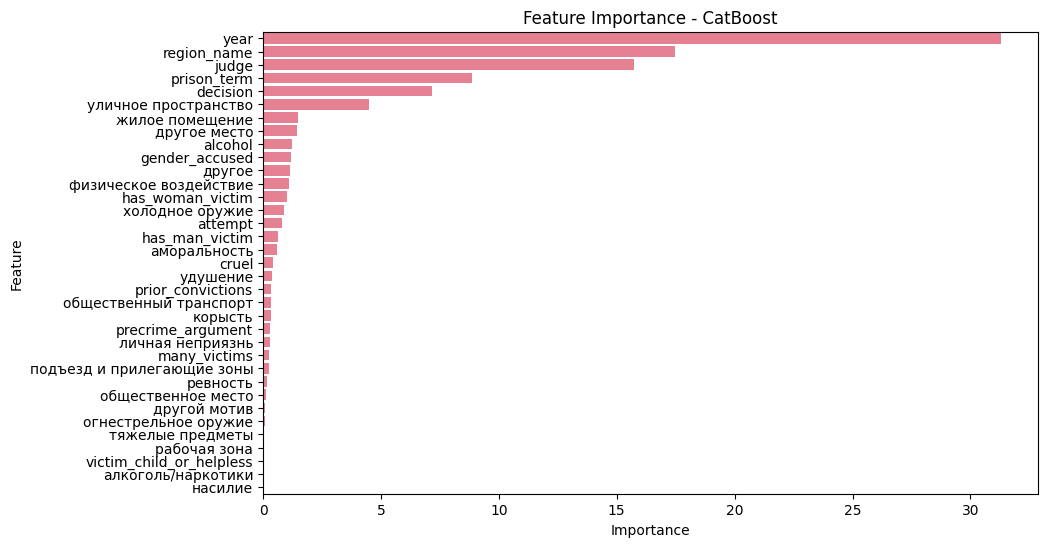

In [278]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
import optuna
import numpy as np

def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance - {model_name}')
    plt.savefig(f'feature_importance_{model_name.lower()}.png')
    return feature_importance

def train_catboost_with_optuna(X_train, y_train, X_val, y_val, X_test, y_test, cat_features):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
            'random_seed': 42,
            'verbose': 0, 
            'early_stopping_rounds': 50
        }
        model = CatBoostClassifier(**params, cat_features=cat_features)
        model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
        val_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_val, val_pred, average="weighted", zero_division=0)
        return f1  

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    best_params = study.best_params
    print("Best CatBoost Params:")
    print(best_params)

    final_params = {
        'iterations': best_params['iterations'],
        'learning_rate': best_params['learning_rate'],
        'depth': best_params['depth'],
        'l2_leaf_reg': best_params['l2_leaf_reg'],
        'bagging_temperature': best_params['bagging_temperature'],
        'random_seed': 42,
        'verbose': 100,
        'early_stopping_rounds': 50
    }
    final_model = CatBoostClassifier(**final_params, cat_features=cat_features)
    final_model.fit(
        pd.concat([X_train, X_val]),
        pd.concat([y_train, y_val]),
    )
    y_pred_catboost = final_model.predict(X_test)

    catboost_accuracy = accuracy_score(y_test, y_pred_catboost)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_catboost, average="weighted", zero_division=0)
    catboost_report = classification_report(y_test, y_pred_catboost)

    catboost_importance = plot_feature_importance(final_model, features, 'CatBoost')

    print("\nCatBoost Results:")
    print(f"Accuracy: {catboost_accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    
    print("\nClassification Report:")
    print(catboost_report)
    print("\nFeature Importance:")
    print(catboost_importance)

    return final_model, catboost_importance

catboost_model, catboost_importance = train_catboost_with_optuna(
    X_train, y_train, X_val, y_val, X_test, y_test, categorical_features)

In [281]:
from joblib import dump

In [283]:
dump(catboost_model, 'catboost_season_model.joblib')

['catboost_season_model.joblib']

In [286]:
target = 'season'

numeric_features = ['prison_term']
categorical_features = ['judge', 'decision', 'year', 'region_name']
other = ['уличное пространство', 'жилое помещение']

features2 = categorical_features + numeric_features + other

X = df[features2]
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train.shape, X_val.shape, X_test.shape 



((22541, 7), (7514, 7), (7514, 7))

[I 2025-04-29 22:43:29,254] A new study created in memory with name: no-name-f8b4978d-a2e9-4ade-8eba-3615ce2422f2
[I 2025-04-29 22:43:31,155] Trial 0 finished with value: 0.1941574523170159 and parameters: {'iterations': 187, 'learning_rate': 0.015231656695243722, 'depth': 5, 'l2_leaf_reg': 9.072420032382364, 'bagging_temperature': 0.9808016561693785}. Best is trial 0 with value: 0.1941574523170159.
[I 2025-04-29 22:43:32,094] Trial 1 finished with value: 0.21229444137619155 and parameters: {'iterations': 168, 'learning_rate': 0.21263872372401163, 'depth': 9, 'l2_leaf_reg': 1.4863662868183898, 'bagging_temperature': 0.15415404062828741}. Best is trial 1 with value: 0.21229444137619155.
[I 2025-04-29 22:43:37,622] Trial 2 finished with value: 0.22779882652878528 and parameters: {'iterations': 865, 'learning_rate': 0.03290917871667422, 'depth': 4, 'l2_leaf_reg': 9.149701601087227, 'bagging_temperature': 0.4473584823461533}. Best is trial 2 with value: 0.22779882652878528.
[I 2025-04-29 2

Best CatBoost Params:
{'iterations': 382, 'learning_rate': 0.12511134285381822, 'depth': 8, 'l2_leaf_reg': 5.57555368548182, 'bagging_temperature': 0.010706042600310939}
0:	learn: 1.3832669	total: 7.67ms	remaining: 2.92s
100:	learn: 1.3263253	total: 2.65s	remaining: 7.38s
200:	learn: 1.3017342	total: 5.68s	remaining: 5.11s
300:	learn: 1.2775994	total: 8.64s	remaining: 2.33s
381:	learn: 1.2601279	total: 11.3s	remaining: 0us

CatBoost Results:
Accuracy: 0.2912
Precision: 0.2863
Recall: 0.2912
F1: 0.2714

Classification Report:
              precision    recall  f1-score   support

       Весна       0.31      0.55      0.39      2106
        Зима       0.29      0.17      0.22      1840
        Лето       0.26      0.23      0.24      1893
       Осень       0.29      0.16      0.21      1675

    accuracy                           0.29      7514
   macro avg       0.29      0.28      0.27      7514
weighted avg       0.29      0.29      0.27      7514


Feature Importance:
             

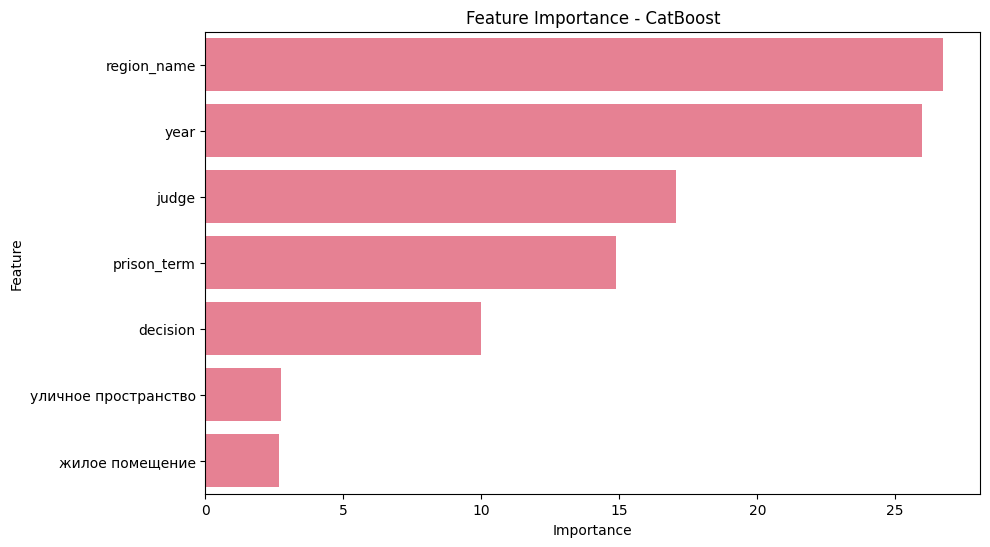

In [287]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
import optuna
import numpy as np

def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance - {model_name}')
    plt.savefig(f'feature_importance_{model_name.lower()}.png')
    return feature_importance

def train_catboost_with_optuna(X_train, y_train, X_val, y_val, X_test, y_test, cat_features):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
            'random_seed': 42,
            'verbose': 0, 
            'early_stopping_rounds': 50
        }
        model = CatBoostClassifier(**params, cat_features=cat_features)
        model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
        val_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_val, val_pred, average="weighted", zero_division=0)
        return f1  

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    best_params = study.best_params
    print("Best CatBoost Params:")
    print(best_params)

    final_params = {
        'iterations': best_params['iterations'],
        'learning_rate': best_params['learning_rate'],
        'depth': best_params['depth'],
        'l2_leaf_reg': best_params['l2_leaf_reg'],
        'bagging_temperature': best_params['bagging_temperature'],
        'random_seed': 42,
        'verbose': 100,
        'early_stopping_rounds': 50
    }
    final_model = CatBoostClassifier(**final_params, cat_features=cat_features)
    final_model.fit(
        pd.concat([X_train, X_val]),
        pd.concat([y_train, y_val]),
    )
    y_pred_catboost = final_model.predict(X_test)

    catboost_accuracy = accuracy_score(y_test, y_pred_catboost)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_catboost, average="weighted", zero_division=0)
    catboost_report = classification_report(y_test, y_pred_catboost)

    catboost_importance = plot_feature_importance(final_model, features2, 'CatBoost')

    print("\nCatBoost Results:")
    print(f"Accuracy: {catboost_accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    
    print("\nClassification Report:")
    print(catboost_report)
    print("\nFeature Importance:")
    print(catboost_importance)

    return final_model, catboost_importance

catboost_model, catboost_importance = train_catboost_with_optuna(
    X_train, y_train, X_val, y_val, X_test, y_test, categorical_features)

In [218]:
# def plot_feature_importance(model, feature_names, model_name):
#     importance = model.feature_importances_
#     feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
#     feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
#     plt.figure(figsize=(10, 6))
#     sns.barplot(x='Importance', y='Feature', data=feature_importance)
#     plt.title(f'Feature Importance - {model_name}')
    
#     return feature_importance

# catboost_model = CatBoostClassifier(
#     iterations=1000,
#     learning_rate=0.1,
#     depth=6,
#     cat_features=categorical_features,
#     verbose=100,
#     random_seed=42
# )

# catboost_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

# y_pred_catboost = catboost_model.predict(X_test)

# catboost_accuracy = accuracy_score(y_test, y_pred_catboost)
# catboost_report = classification_report(y_test, y_pred_catboost)

# catboost_importance = plot_feature_importance(catboost_model, features, 'CatBoost')

# print("CatBoost Results:")
# print(f"Accuracy: {catboost_accuracy:.4f}")

# print("\nClassification Report:")
# print(catboost_report)
# print("\nFeature Importance:")
# print(catboost_importance)


RandomForest

In [192]:
print("Inf:", np.isinf(df['prison_term']).sum())
print("Большие значения (>1e308):", (df['prison_term'].abs() > 1e308).sum())

Inf: 11
Большие значения (>1e308): 11


In [193]:
def clean_prison_term(df, column='prison_term'):
    df[column] = df[column].replace([np.inf, -np.inf], np.nan)
    df[column] = df[column].clip(upper=1e308, lower=-1e308)
    return df

df = clean_prison_term(df.copy(), 'prison_term')

X_train['prison_term'] = df.loc[X_train.index, 'prison_term']
X_val['prison_term'] = df.loc[X_val.index, 'prison_term']
X_test['prison_term'] = df.loc[X_test.index, 'prison_term']

In [246]:
def group_top_categories(df, column, top_n=10, other_label='другое'):
    top_categories = df[column].value_counts().nlargest(top_n).index
    
    df[column] = df[column].apply(lambda x: x if x in top_categories else other_label)
    return df

In [247]:
df = group_top_categories(df, 'judge', top_n=8, other_label='другое судьи')
df = group_top_categories(df, 'region_name', top_n=8, other_label='другое регионы')
df = group_top_categories(df, 'year', top_n=8, other_label='другое год')
df['year'] = df['year'].astype(str)
df['year'].value_counts()

year
2016          6090
2017          5894
2018          4935
2020          4446
2021          4293
2019          4172
2022          4031
2023          2380
другое год    1328
Name: count, dtype: int64

In [231]:
X_train['judge'] = df.loc[X_train.index, 'judge']
X_val['judge'] = df.loc[X_val.index, 'judge']
X_test['judge'] = df.loc[X_test.index, 'judge']

X_train['region_name'] = df.loc[X_train.index, 'region_name']
X_val['region_name'] = df.loc[X_val.index, 'region_name']
X_test['region_name'] = df.loc[X_test.index, 'region_name']

X_train['year'] = df.loc[X_train.index, 'year']
X_val['year'] = df.loc[X_val.index, 'year']
X_test['year'] = df.loc[X_test.index, 'year']

In [232]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('scaling', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  # Заменяем NaN на медиану
        ('scaler', StandardScaler())
    ]), numeric_features),
])

X_train2 = column_transformer.fit_transform(X_train)
X_val2 = column_transformer.transform(X_val)
X_test2 = column_transformer.transform(X_test)
feature_names2 = column_transformer.get_feature_names_out()

In [ ]:
# column_transformer = ColumnTransformer([
#     ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
#     ('scaling', StandardScaler(), numeric_features),
# ])

In [235]:
# def plot_feature_importance(model, feature_names, model_name):
#     importance = model.feature_importances_
#     feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
#     feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
#     # plt.figure(figsize=(10, 6))
#     # sns.barplot(x='Importance', y='Feature', data=feature_importance)
#     # plt.title(f'Feature Importance - {model_name}')
    
#     return feature_importance

# rf_model = RandomForestClassifier(
#     n_estimators=1000,  
#     max_depth=6,      
#     random_state=42,   
#     verbose=1,         
#     n_jobs=-1          
# )

# rf_model.fit(X_train2, y_train)

# y_pred_rf = rf_model.predict(X_test2)

# rf_accuracy = accuracy_score(y_test, y_pred_rf)

# rf_report = classification_report(y_test, y_pred_rf)

# rf_importance = plot_feature_importance(rf_model, feature_names2, 'RandomForest')

# print("RandomForest Results:")
# print(f"Accuracy: {rf_accuracy:.4f}")
# print("\nClassification Report:")
# print(rf_report)
# print("\nFeature Importance:")
# print(rf_importance)

[I 2025-04-29 19:34:16,230] A new study created in memory with name: no-name-334369e3-a8b6-4d6a-8e28-ee78fd2c3658
[I 2025-04-29 19:34:16,525] Trial 0 finished with value: 0.23087948737943173 and parameters: {'n_estimators': 214, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.23087948737943173.
[I 2025-04-29 19:34:19,244] Trial 1 finished with value: 0.2368498987402581 and parameters: {'n_estimators': 806, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False}. Best is trial 1 with value: 0.2368498987402581.
[I 2025-04-29 19:34:20,934] Trial 2 finished with value: 0.26198686500901874 and parameters: {'n_estimators': 571, 'max_depth': 26, 'min_samples_split': 19, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': True}. Best is trial 2 with value: 0.26198686500901874.
[I 2025-04-29 19:34:21,502] Trial 3 finished with value: 0.2486296182473

Best RandomForest Params:
{'n_estimators': 109, 'max_depth': 30, 'min_samples_split': 16, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': True}

RandomForest Results:
Accuracy: 0.2781
Precision: 0.2688
Recall: 0.2781
F1: 0.2653

Classification Report:
              precision    recall  f1-score   support

       Весна       0.31      0.47      0.37      2106
        Зима       0.27      0.24      0.26      1840
        Лето       0.26      0.21      0.23      1893
       Осень       0.23      0.14      0.18      1675

    accuracy                           0.28      7514
   macro avg       0.27      0.27      0.26      7514
weighted avg       0.27      0.28      0.27      7514


Feature Importance:
                                              Feature  Importance
30                               scaling__prison_term    0.621785
20                               ohe__year_другое год    0.077364
29                    ohe__region_name_другое регионы    0.052571
12                

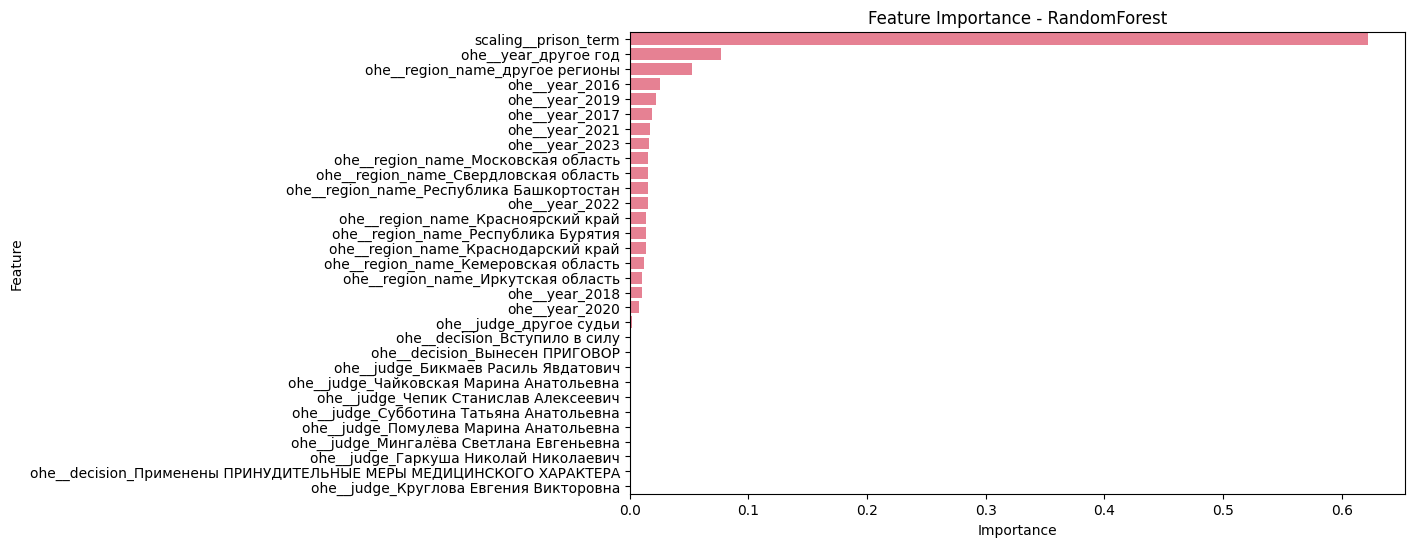

In [237]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import optuna
import numpy as np

def plot_feature_importance(model, feature_names, model_name):
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title(f'Feature Importance - {model_name}')
    plt.savefig(f'feature_importance_{model_name.lower()}.png')
    return feature_importance

def train_random_forest_with_optuna(X_train, y_train, X_val, y_val, X_test, y_test, feature_names):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'random_state': 42,
            'n_jobs': -1,
            'verbose': 0
        }
        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_val, val_pred, average="weighted", zero_division=0)
        return f1 

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    best_params = study.best_params
    print("Best RandomForest Params:")
    print(best_params)

    # final_params = {
    #     'n_estimators': best_params['n_estimators'],
    #     'max_depth': best_params['max_depth'],
    #     'min_samples_split': best_params['min_samples_split'],
    #     'min_samples_leaf': best_params['min_samples_leaf'],
    #     'max_features': best_params['max_features'],
    #     'bootstrap': best_params['bootstrap'],
    #     'random_state': 42,
    #     'n_jobs': -1,
    #     'verbose': 1
    # }
    
    final_model = RandomForestClassifier(**best_params)
    final_model.fit(
        np.vstack([X_train, X_val]),
        np.hstack([y_train, y_val])
    )

    y_pred_rf = final_model.predict(X_test)

    rf_accuracy = accuracy_score(y_test, y_pred_rf)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_rf, average="weighted", zero_division=0)
    rf_report = classification_report(y_test, y_pred_rf)

    rf_importance = plot_feature_importance(final_model, feature_names, 'RandomForest')

    print("\nRandomForest Results:")
    print(f"Accuracy: {rf_accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    
    print("\nClassification Report:")
    print(rf_report)
    print("\nFeature Importance:")
    print(rf_importance)

    return final_model, rf_importance

rf_model, rf_importance = train_random_forest_with_optuna(
    X_train2, y_train, X_val2, y_val, X_test2, y_test, feature_names2
)

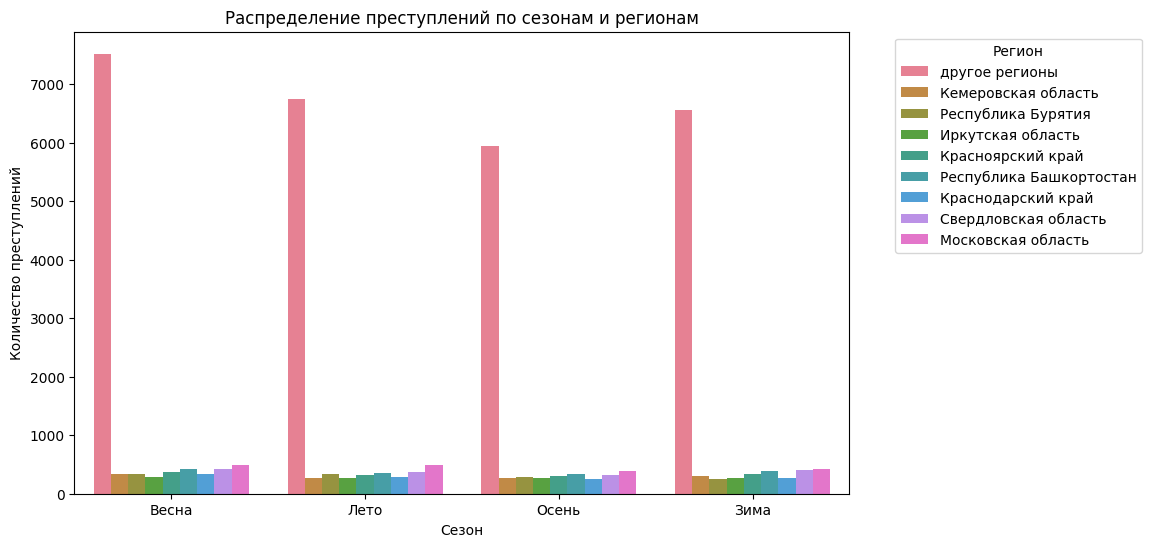

In [248]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='season', hue='region_name', order=['Весна', 'Лето', 'Осень', 'Зима'])
plt.title('Распределение преступлений по сезонам и регионам')
plt.xlabel('Сезон')
plt.ylabel('Количество преступлений')
plt.legend(title='Регион', bbox_to_anchor=(1.05, 1), loc='upper left')

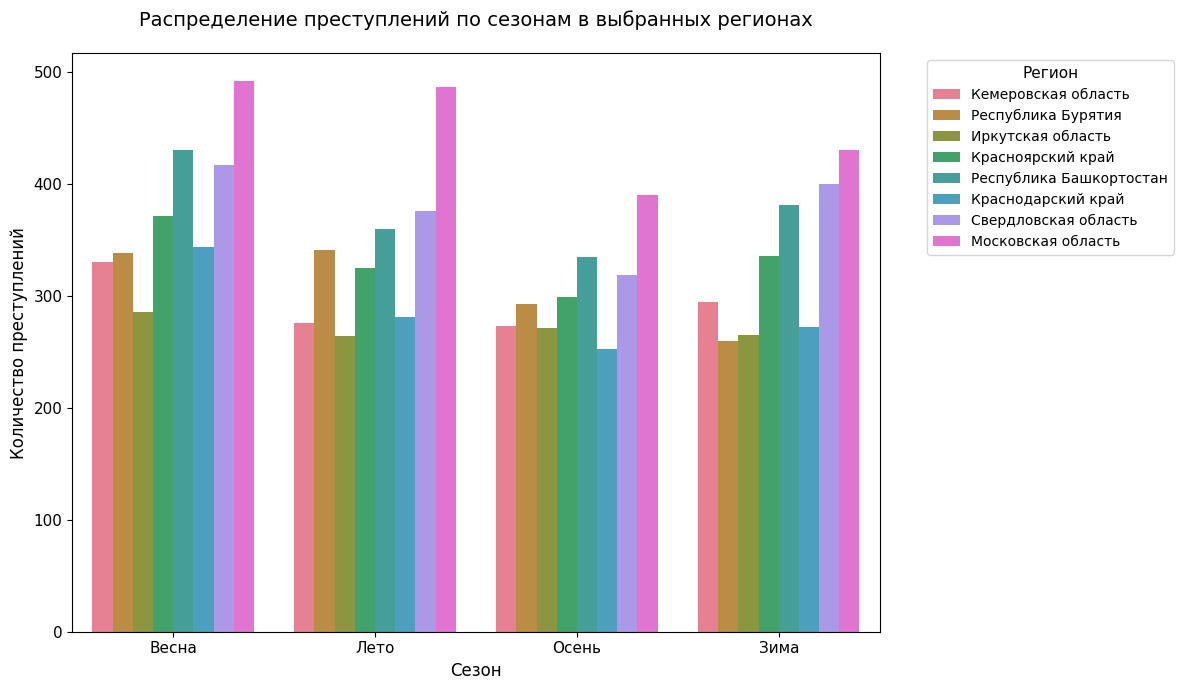

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

target_regions = [
    'Московская область', 
    'Свердловская область',
    'Республика Башкортостан',
    'Красноярский край',
    'Республика Бурятия',
    'Кемеровская область',
    'Краснодарский край',
    'Иркутская область'
]

df_filtered = df[df['region_name'].isin(target_regions)]

season_order = ['Весна', 'Лето', 'Осень', 'Зима']

plt.figure(figsize=(12, 7))
sns.countplot(
    data=df_filtered,
    x='season',
    hue='region_name',
    order=season_order
)

plt.title('Распределение преступлений по сезонам в выбранных регионах', fontsize=14, pad=20)
plt.xlabel('Сезон', fontsize=12)
plt.ylabel('Количество преступлений', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(
    title='Регион',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.show()